In [24]:
import pandas as pd
import numpy as np

In [2]:
rng = np.random.default_rng(42)

df_sampling = pd.DataFrame(
    {
        "user_id": np.arange(1,101),
        "category": rng.choice(["A","B", "C"], size=100, p=[0.5, 0.3, 0.2]),
        "score": rng.normal(loc=75, scale=10, size=100).round(2)
    }
)

In [4]:
print(f'The shape of the DataFrame: {df_sampling.shape}')
print(f'The columns of the DataFrame: {df_sampling.columns}')
df_sampling.head()

The shape of the DataFrame: (100, 3)
The columns of the DataFrame: Index(['user_id', 'category', 'score'], dtype='str')


,user_id,category,score
0,1,B,79.00
1,2,A,65.95
2,3,C,71.22
3,4,B,87.99
4,5,A,71.44


In [5]:
df_sampling['score'].describe()[['mean', 'std', 'min', 'max']]

mean     74.859800
std       9.843752
min      53.680000
max     104.140000
Name: score, dtype: float64

In [3]:
df_sampling['category'].value_counts().sort_index()

category
A    53
B    33
C    14
Name: count, dtype: int64

In [4]:
df_sampling.groupby('category')['score'].describe()[['mean','std','min','max']]

,mean,std,min,max
category,,,,
A,74.200000,8.973076,60.29,94.97
B,76.272424,10.014058,58.25,96.28
C,74.027857,12.705514,53.68,104.14


In [5]:
#Random sampling
random_sample = df_sampling.sample(n=20, random_state=42)
random_sample.shape

(20, 3)

In [6]:
random_sample.groupby('category')['score'].describe()[['mean','std', 'min', 'max']]

,mean,std,min,max
category,,,,
A,71.211250,8.747513,61.23,83.40
B,75.071429,6.553916,64.64,83.38
C,67.838000,10.015841,53.68,77.68


In [7]:
random_sample['category'].value_counts().sort_index()

category
A    8
B    7
C    5
Name: count, dtype: int64

In [9]:
#Stratified Sampling | proportional to the category distribution
stratified_sample = (
    df_sampling
    .groupby("category", group_keys=False)
    .sample(frac=0.2, random_state=42)
    .reset_index(drop=True)
)

In [10]:
stratified_sample.head()

,user_id,category,score
0,39,A,78.14
1,84,A,77.19
2,93,A,92.24
3,29,A,89.63
4,86,A,86.06


In [11]:
stratified_sample.groupby('category')['score'].describe()[['mean', 'std', 'min', 'max']]

,mean,std,min,max
category,,,,
A,76.688182,10.510287,60.29,92.24
B,78.715714,10.081969,66.79,92.68
C,63.650000,5.447054,57.73,68.45


In [12]:
stratified_sample['category'].value_counts().sort_index()

category
A    11
B     7
C     3
Name: count, dtype: int64

In [13]:
stratified_sample['category'].value_counts(normalize=True).sort_index()

category
A    0.523810
B    0.333333
C    0.142857
Name: proportion, dtype: float64

In [14]:
stratified_sample['category'].value_counts(normalize=True).sort_index()

category
A    0.523810
B    0.333333
C    0.142857
Name: proportion, dtype: float64

In [ ]:
#Stratified Sampling | Equal number of samples from each category
stratified_sample = (
    df_sampling
    .groupby("category", group_keys=False)
    .sample(n=10, random_state=42)
    .reset_index(drop=True)
)

In [17]:
df_sampling['category'].value_counts()

category
A    53
B    33
C    14
Name: count, dtype: int64

In [18]:
#Splitting the data into control and treatment groups
rng = np.random.default_rng(42)

df_random_split = df_sampling.assign(
    group=rng.choice(["control", "treatment"], size=len(df_sampling))
)

In [20]:
df_random_split['group'].value_counts()

group
treatment    52
control      48
Name: count, dtype: int64

In [21]:
#Stratified Splitting
df_stratified_split = (
    df_sampling
    .assign(
        group=lambda x: (
            x.groupby("category")["user_id"]
            .transform(
                lambda g: rng.permutation(
                    ["control"] * (len(g)//2) + 
                    ["treatment"] * (len(g) - len(g)//2)
                )
            )
        )
    )
)

In [22]:
df_stratified_split[['group', 'category']].value_counts()

group      category
treatment  A           27
control    A           26
treatment  B           17
control    B           16
treatment  C            7
control    C            7
Name: count, dtype: int64

In [30]:
#Power Analysis With Python
import numpy as np
import pandas as pd
import math
from statsmodels.stats.power import TTestIndPower
from statsmodels.stats.multitest import multipletests 
from scipy.stats import ttest_ind
import scipy
import matplotlib.pyplot as plt

In [32]:
#Calculating Sample Size
N = TTestIndPower().solve_power(effect_size = 0.4, power = 0.8,
                                alpha = 0.05)

N

99.08032514676705

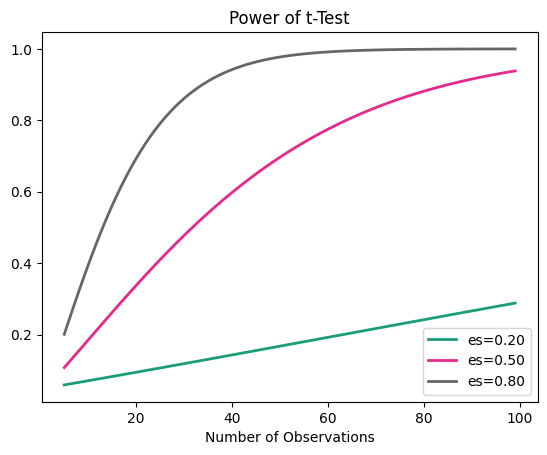

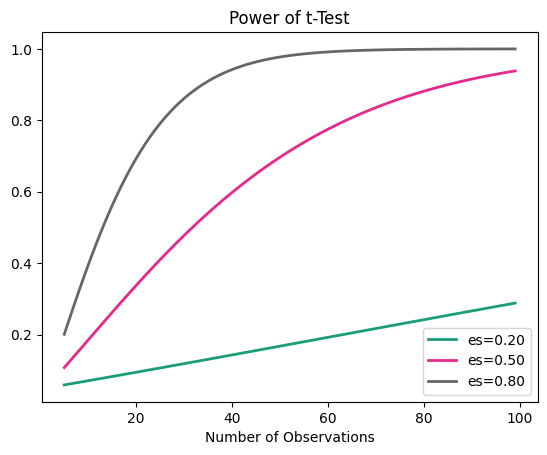

In [34]:
#Sampling distributions
TTestIndPower().plot_power(dep_var='nobs',
                           nobs=np.array(range(5,100)),
                           effect_size=np.array([0.2, 0.5, 0.8]),
                           title='Power of t-Test')


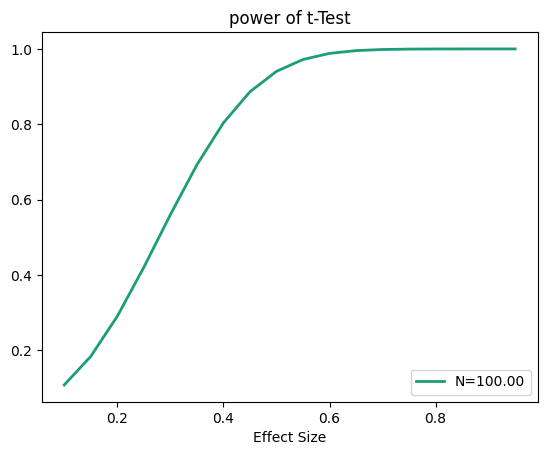

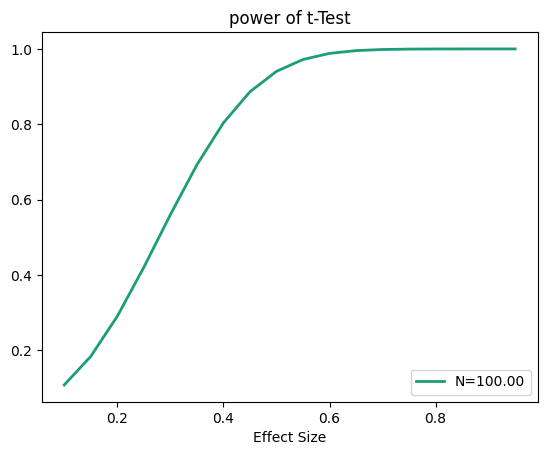

In [35]:
TTestIndPower().plot_power(dep_var='effect_size', nobs=[100],
                           effect_size=np.arange(0.1, 1, 0.05),
                           title='power of t-Test')

In [36]:
TTestIndPower().solve_power(effect_size = 0.365, power = 0.8,
                            alpha = 0.05, alternative = 'larger')

93.4975695136995

In [38]:
#Loading the data
expr = pd.read_csv('../data/ab_testing/experiment.csv')
expr.head()

,user_id,viewing_time,Group
0,4b5630ee914e848e8d07221556b0a2fb,38.354937,control
1,c01f179e4b57ab8bd9de309e6d576c48,49.534278,control
2,11946e7a3ed5e1776e81c0f0ecd383d0,35.468325,control
3,234a2a5581872457b9fe1187d1616b13,69.014875,control
4,dd4ad37ee474732a009111e3456e7ed7,51.547207,control


In [39]:
expr.groupby('Group')['viewing_time'].mean()

Group
control      48.386186
treatment    52.081302
Name: viewing_time, dtype: float64

In [40]:
#T-test
#T-test with scipy:
ctrl = expr[expr['Group'] == 'control']['viewing_time']
treatment = expr[expr['Group'] == 'treatment']['viewing_time']


In [41]:
test_res = ttest_ind(treatment, ctrl)
tstat, pvalue=test_res

In [42]:
f"t-statistics: {tstat:.4f}"

't-statistics: 1.6002'

In [43]:
f"p-value: {pvalue:.4f}"

'p-value: 0.1128'

In [44]:
#Interpretation
diff=treatment.mean() - ctrl.mean()
sd_pooled=math.sqrt((treatment.std()**2+ ctrl.std()**2)/2)

In [45]:
f"The detected Effect: {diff/sd_pooled:.4f}"

'The detected Effect: 0.3200'

In [47]:
#Practical Significance
#Case 1 | low variance
case1=pd.read_csv("../data/ab_testing/case1.csv")
case1.head()


,score1,score2
0,85,87
1,85,86
2,86,87
3,86,86
4,85,86


In [48]:
case1.describe().loc[['count','mean','std']]

,score1,score2
count,20.000000,20.000000
mean,85.550000,86.400000
std,0.510418,0.502625


In [49]:
#Case 2 | huge sample size
case2=pd.read_csv("../data/ab_testing/case2.csv")
case2.head()

,score1,score2
0,88,95
1,89,88
2,91,93
3,94,87
4,87,89


In [50]:
case2.describe().loc[['count','mean','std']]

,score1,score2
count,20.000000,20.000000
mean,90.650000,90.750000
std,2.777257,2.788605


#### Utils Functions


In [51]:
def measures(data):
    x1=data.describe().loc['mean','score1']
    x2=data.describe().loc['mean','score2']
    s1=data.describe().loc['std','score1']
    s2=data.describe().loc['std','score2']
    return x1,x2,s1,s2

In [55]:
def ttest(x1,x2,s1,s2,n):
    t_value=(x1-x2)/math.sqrt(s1**2/n+s2**2/n)
    p_value=scipy.stats.t.sf(abs(t_value), df=n-1)*2
    return f't-value: {t_value:.4f}', f'p-value: {p_value:.4f}'

In [56]:
  #Case 1 | Experiment
# t-test for case
c1=measures(case1)
ttest(*c1,20)
  

('t-value: -5.3065', 'p-value: 0.0000')

In [ ]:
#Case 2 | Experiment
#N=20
c2=measures(case2)
ttest(*c2,20)


('t-value: -0.1136', 'p-value: 0.9107')

In [ ]:

#N=200
c2=measures(case2)
ttest(*c2,200)

('t-value: -0.3593', 'p-value: 0.7197')

In [ ]:
#N=2000
c2=measures(case2)
ttest(*c2,2000)

('t-value: -1.1363', 'p-value: 0.2560')

In [ ]:
#N=20000
c2=measures(case2)
ttest(*c2,20000)

('t-value: -3.5933', 'p-value: 0.0003')

In [62]:
#Libraries
import matplotlib.pyplot as plt
from scipy import stats
from statsmodels.stats.multitest import multipletests

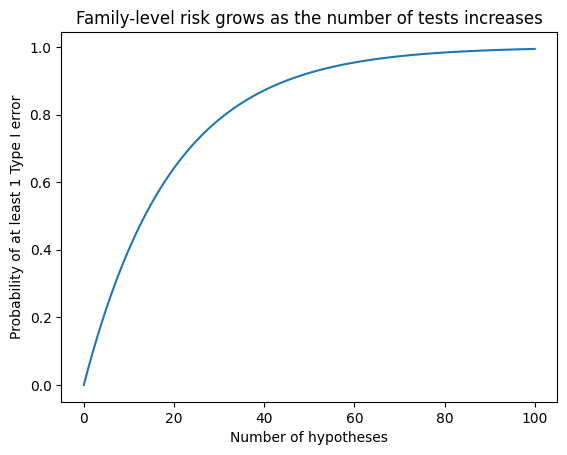

In [63]:
#Type I error curve
m_tests = np.arange(0, 101)
prob_at_least_one_error = 1 - (1 - 0.05) ** m_tests

plt.figure()
plt.plot(m_tests, prob_at_least_one_error)
plt.xlabel("Number of hypotheses")
plt.ylabel("Probability of at least 1 Type I error")
plt.title("Family-level risk grows as the number of tests increases")
plt.show()

In [66]:
#Loading the data
experiment_m = pd.read_csv("../data/ab_testing/experiment_m.csv")
groups = sorted(experiment_m["group"].dropna().unique())

In [67]:
group_counts = (
    experiment_m.groupby("group", as_index=False)
    .size()
    .rename(columns={"size": "n"})
)

group_counts

,group,n
0,Test1,200
1,Test2,200
2,Test3,200
3,Test4,200
4,Test5,200
5,Test6,200
6,Test7,200
7,Test8,200
8,Test9,200
9,control,200


In [68]:
#Pairwise t-test without adjustment
pairwise_results = pairwise_ttests(
    experiment_m,
    value_col="viewing_time",
    group_col="group"
)

pairwise_results.head()

NameError: name 'pairwise_ttests' is not defined

In [ ]:
``